In [1]:
import numpy as np
import pandas as pd

df = pd.read_csv('./files/cleaned_dataset.csv')

In [2]:
df.head()

,Book Name,Author,Rating,Number of Reviews,Price,Description,Listening Time (minutes),Genre,Rank
0,Think Like a Monk: The Secret of How to Harnes...,Jay Shetty,4.9,313,10080.0,"Over the past three years, Jay Shetty has beco...",654.0,Personal Success,1
1,Ikigai: The Japanese Secret to a Long and Happ...,Héctor García,4.6,3658,615.0,Brought to you by Penguin.,203.0,Meditation,1
2,The Subtle Art of Not Giving a F*ck: A Counter...,Mark Manson,4.4,20174,10378.0,"In this generation-defining self-help guide, a...",317.0,Personal Success,3
3,Atomic Habits: An Easy and Proven Way to Build...,James Clear,4.6,4614,888.0,Brought to you by Penguin.,335.0,Psychology,1
4,Life's Amazing Secrets: How to Find Balance an...,Gaur Gopal Das,4.6,4302,1005.0,"Stop going through life, Start growing throug...",385.0,Literary Essays,1


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3025 entries, 0 to 3024
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Book Name                 3025 non-null   object 
 1   Author                    3025 non-null   object 
 2   Rating                    3025 non-null   float64
 3   Number of Reviews         3025 non-null   int64  
 4   Price                     3025 non-null   float64
 5   Description               3025 non-null   object 
 6   Listening Time (minutes)  3025 non-null   float64
 7   Genre                     3025 non-null   object 
 8   Rank                      3025 non-null   int64  
dtypes: float64(3), int64(2), object(4)
memory usage: 212.8+ KB


# Preprocessing Text Columns

Convert to lowercase

Remove punctuation and stopwords

Apply lemmatization

Combine Book Name and Description into a single text field

In [6]:
import re

import nltk

nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Lenovo\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Lenovo\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [8]:
import string
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

In [9]:
def preprocess_text(text):
    text = str(text).lower()
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    tokens = text.split()
    tokens = [lemmatizer.lemmatize(word) for word in tokens if word not in stop_words and word not in string.punctuation]
    return ' '.join(tokens)

In [10]:
df['combined_text'] = df['Book Name'] + ' ' + df['Description']

df['cleaned_text'] = df['combined_text'].apply(preprocess_text)

In [11]:
df['cleaned_text'].head()

0    think like monk secret harness power positivit...
1    ikigai japanese secret long happy life brought...
2    subtle art giving fck counterintuitive approac...
3    atomic habit easy proven way build good habit ...
4    life amazing secret find balance purpose life ...
Name: cleaned_text, dtype: object

# TF-IDF vectorzer

Transform text into numerical vectors

In [12]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=1000)
X = tfidf.fit_transform(df['cleaned_text'])

# K-Means

In [15]:
from sklearn.cluster import KMeans

inertia = []
k_range = range(2, 11)
for k in k_range:
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(X)
    inertia.append(km.inertia_)

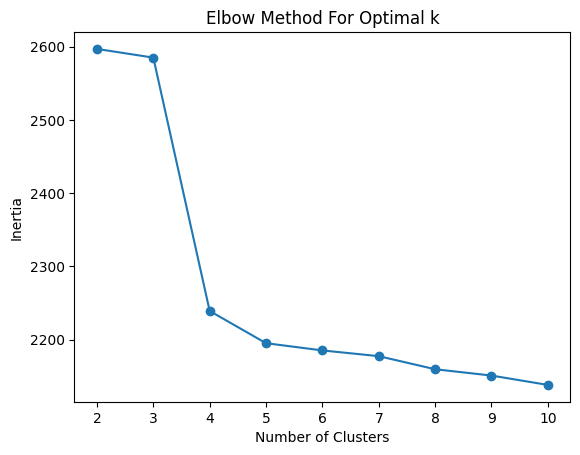

In [16]:
import matplotlib.pyplot as plt

plt.plot(k_range, inertia, marker='o')
plt.xlabel('Number of Clusters')
plt.ylabel('Inertia')
plt.title('Elbow Method For Optimal k')
plt.show()

In [ ]:
kmeans = KMeans(n_clusters=4, random_state=42)

df['cluster'] = kmeans.fit_predict(X)

In [18]:
df['cluster'].value_counts()

cluster
3    1760
1     666
2     394
0     205
Name: count, dtype: int64

## PCA

In [19]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
components = pca.fit_transform(X.toarray())

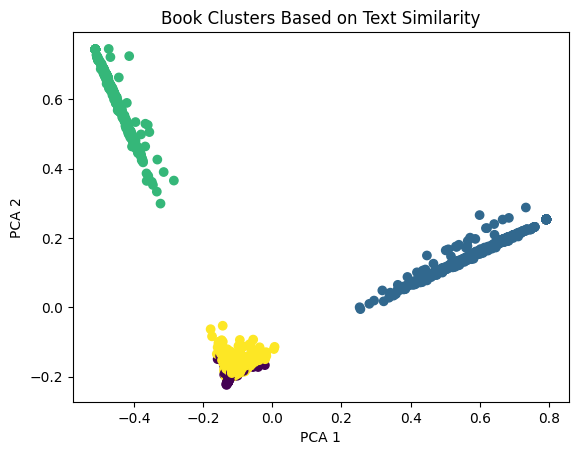

In [20]:
import matplotlib.pyplot as plt

plt.scatter(components[:, 0], components[:, 1], c=df['cluster'])
plt.title('Book Clusters Based on Text Similarity')
plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.show()

In [21]:
df.to_csv("./files/clustered_books.csv",index=False)